# Synthetic Options on the MSCI ACWI

**Objective:** price and quote options on the iShares MSCI ACWI ETF in the absence of a liquid options market on the index.

**Methodology:**
1. **Data.** Daily closes from 2018-02-24 to 2024-02-24 are downloaded from Yahoo Finance for the ACWI ETF and 10 ETFs representing the countries with the largest weights in the index. Returns and volatilities are computed on **adjusted** closes (dividends are not risk); pricing uses **traded** (unadjusted) prices, which are the terms in which the strikes are quoted.
2. **Replicating regression.** OLS of ACWI log returns on the ETFs' log returns; all ten ETFs are individually significant, so every trim is for parsimony, not significance: the intercept (p = 0.40) and the three smallest legs (INDA, EWC, EWT, each under 4% of the basket) are dropped, and EWQ goes as a near-duplicate of EWG (ρ = 0.95), one core-Europe leg is enough for a basket that is only ever traded as a whole, and the fit is unchanged without it (R² = 0.993 vs 0.994 with all ten). The 6-ETF basket defines the **synthetic ACWI**. The model assumptions are validated and a \$1M portfolio in the ACWI is compared against the synthetic one.
3. **Market parameters as of the valuation date (2023-02-24).** A single USD risk-free rate for all the ETFs (they are USD-denominated assets), taken from the 1-year Treasury (FRED DGS1) on that date; each ETF's dividend yield as the average of the previous 5 years (total return vs price return, which smooths extraordinary distributions); two volatility estimates computable on that date: historical (5 years) and EWMA (RiskMetrics, λ=0.94).
4. **Pricing.** Three options are quoted with Black-Scholes with dividends: a 9m call struck at \$85, a 9m digital call struck at \$87 and a 12m call spread struck at \$78/\$100. Each is replicated as a basket of options on the component ETFs, $n_i = w_i \cdot S_{ACWI}/S_i$ units of the option on leg $i$, so every leg contributes its regression weight in *dollar* terms with strikes that preserve the moneyness ($K_i = S_i \cdot K/S_{ACWI}$), tracking the daily mark-to-market. For convex payoffs the basket of options **super-replicates** the option on the basket (imperfect correlations make it worth more); that correlation premium is quantified against the option priced directly on the synthetic index, and the implied volatility embedded in the quote is extracted. Every emitted quote is guarded by explicit no-arbitrage bound assertions, and the two near-strike products (the digital and the spread) are sensitivity-tested against a volatility skew. The dimension flat-vol Black-Scholes ignores and the one that hits them hardest.
5. **Validation.** Stability of the regression weights on a rolling window; a daily delta-hedging backtest (each option is sold at the quoted premium and hedged with the synthetic underlying until expiry, reporting the P&L); and a Monte Carlo in which the six legs are simulated **jointly at their historical correlation**, so the correlation premium embedded in each quote shows up as realized hedging P&L and every backtest number gets a confidence band.

## Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from scipy.optimize import brentq
from scipy.stats import norm

%matplotlib inline

## Data and log returns

`data` (adjusted closes) for returns, regression and volatilities; `prices` (traded closes) for strikes and pricing.

In [2]:
start_date, end_date = '2018-02-24', '2024-02-24'
tickers = ['IVV', 'EWJ', 'EWU', 'MCHI', 'EWC', 'EWQ', 'EWG', 'EWL', 'INDA', 'EWT']

raw = yf.download(['ACWI'] + tickers, start=start_date, end=end_date, auto_adjust=False)
data = raw['Adj Close'][['ACWI'] + tickers]
prices = raw['Close'][['ACWI'] + tickers]

# every fund distributes over this window, so total return must beat price return;
# otherwise Yahoo served closes with the dividend adjustment missing, re-run this cell
assert ((data.iloc[-1] / data.iloc[0]) > (prices.iloc[-1] / prices.iloc[0])).all(), 'dividend adjustment missing'

returns = np.log(data / data.shift(1)).dropna()
data.tail()


[                       0%                       ]
[                       0%                       ]


[*************         27%                       ]  3 of 11 completed


[*************         27%                       ]  3 of 11 completed


[**********************45%                       ]  5 of 11 completed


[**********************55%*                      ]  6 of 11 completed
[**********************55%*                      ]  6 of 11 completed


[**********************73%**********             ]  8 of 11 completed


[**********************82%**************         ]  9 of 11 completed


[**********************91%*******************    ]  10 of 11 completed


[*********************100%***********************]  11 of 11 completed

Ticker,ACWI,IVV,EWJ,EWU,MCHI,EWC,EWQ,EWG,EWL,INDA,EWT
Date,,,,,,,,,,,
2024-02-16,101.062340,486.301392,62.863758,29.763834,36.828735,35.141846,36.039486,27.778183,44.092209,50.832245,42.675423
2024-02-20,100.774101,483.598328,63.142624,29.927773,36.524918,35.007713,36.399055,27.844074,44.611832,51.189659,42.990234
2024-02-21,100.802917,484.034332,63.012482,29.736509,37.293957,34.959812,36.611103,27.966444,44.715759,50.812389,42.582832
2024-02-22,102.541908,494.148834,64.044266,29.955093,37.759186,35.295135,37.044426,28.427692,44.517357,51.358437,43.221714
2024-02-23,102.580330,494.429749,64.146523,30.064386,37.882610,35.438850,37.191940,28.446516,44.772442,51.427933,42.971718


## Linear regression

In [3]:
y = returns['ACWI']
X = sm.add_constant(returns[tickers])
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   ACWI   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 2.705e+04
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:56:38   Log-Likelihood:                 8434.2
No. Observations:                1508   AIC:                        -1.685e+04
Df Residuals:                    1497   BIC:                        -1.679e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.987e-05   2.34e-05     -0.850      0.3

Only the intercept fails the significance test (p = 0.40); every ETF is individually significant (smallest |t| ≈ 6.8), so significance gives no reason to trim the basket. For parsimony, each name kept is one more leg to trade in every option quote and hedge below. The intercept and the three smallest coefficients in the table above (INDA, EWC, EWT, each under 4% of the basket) are dropped. The surviving legs are then screened for redundancy with variance inflation factors:

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = X.drop(columns=['INDA', 'EWC', 'EWT', 'const'])
pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
          index=X.columns, name='VIF').round(1)

IVV      4.0
EWJ      3.0
EWU      6.0
MCHI     1.5
EWQ     13.8
EWG     11.0
EWL      4.5
Name: VIF, dtype: float64

EWQ and EWG are near-duplicates (ρ = 0.95, see the correlation matrix further down): they carry the same core-Europe factor, which is what their VIFs of ≈ 14 and ≈ 11 are signalling. For a basket that is only ever traded and hedged as a whole, the inflated *individual* standard errors behind a high VIF are not themselves a problem, the reason to drop a leg is parsimony: two near-identical legs mean one more option to price and one more hedge to run in every quote, for no additional information. EWQ goes (dropping either leaves R² at 0.993) and the 6-ETF model is re-estimated with heteroskedasticity-robust (HC3) errors:

In [5]:
X = X.drop(columns=['EWQ'])
final_model = sm.OLS(y, X).fit(cov_type='HC3')
print(final_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                   ACWI   R-squared (uncentered):                   0.993
Model:                            OLS   Adj. R-squared (uncentered):              0.993
Method:                 Least Squares   F-statistic:                              9205.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):                        0.00
Time:                        13:56:38   Log-Likelihood:                          8241.4
No. Observations:                1508   AIC:                                 -1.647e+04
Df Residuals:                    1502   BIC:                                 -1.644e+04
Df Model:                           6                                                  
Covariance Type:                  HC3                                                  
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

### Why the ETF and not the index as the target?

The MSCI ACWI index (`data/IndexMSCI.csv`) is computed from each regional market's close, while every ETF in the basket closes at the same time on NYSE. That timing mismatch misaligns the daily returns and hurts the regression R² without the basket replicating any worse. The replication target is therefore the ACWI ETF: it shares the basket's closing time and is also the underlying in whose terms the strikes are quoted.

In [6]:
msci_index = pd.read_csv('data/IndexMSCI.csv', encoding='utf-8-sig', parse_dates=['Date'], index_col='Date')
r_index = np.log(msci_index / msci_index.shift(1)).dropna()['MSCI ACWI Index']
common = returns.index.intersection(r_index.index)
index_model = sm.OLS(r_index.loc[common], returns.loc[common, X.columns]).fit()

print(f'R² replicating the MSCI index (regional closes): {index_model.rsquared:.3f}')
print(f'R² replicating the ACWI ETF (NYSE close):        {final_model.rsquared:.3f}')

R² replicating the MSCI index (regional closes): 0.945
R² replicating the ACWI ETF (NYSE close):        0.993


### Coefficient stability

The regression is re-estimated on a 2-year rolling window (504 trading days). The weights move gradually and with no regime changes, which makes replicating with static weights over the valuation period defensible.

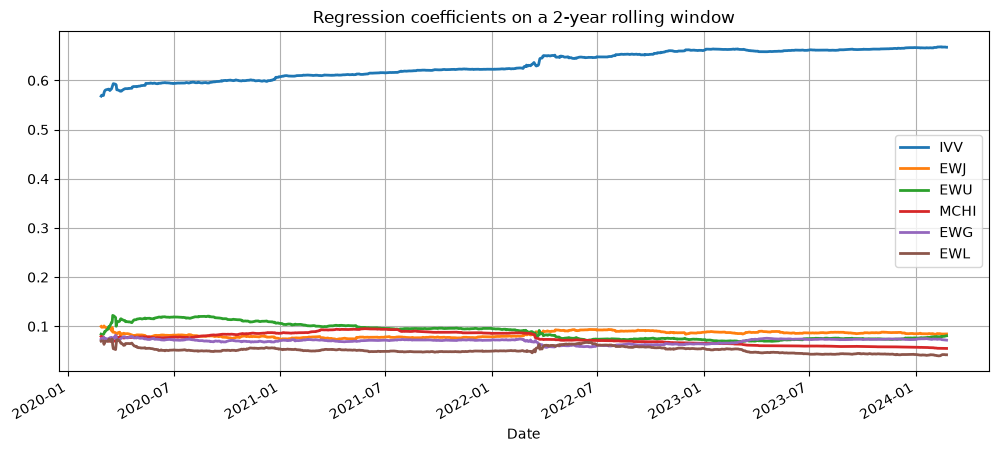

,IVV,EWJ,EWU,MCHI,EWG,EWL
Date,,,,,,
2020-02-27,0.568,0.100,0.084,0.079,0.074,0.070
2024-02-23,0.667,0.084,0.081,0.055,0.072,0.042


In [7]:
from statsmodels.regression.rolling import RollingOLS

betas = RollingOLS(y, X, window=504).fit().params.dropna()
betas.plot(figsize=(12, 5), linewidth=2, title='Regression coefficients on a 2-year rolling window')
plt.grid(True)
plt.show()
betas.iloc[[0, -1]].round(3)

## Residual analysis

No VIF exceeds the ≈ 10 bar after the screen; the surviving European legs still co-move, which widens their individual confidence intervals but not the joint fit. The basket is only ever traded as a whole, never interpreted coefficient by coefficient.

In [8]:
# Multicollinearity
pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
          index=X.columns, name='VIF').round(2)

IVV     3.99
EWJ     2.99
EWU     5.12
MCHI    1.54
EWG     6.00
EWL     4.35
Name: VIF, dtype: float64

In [9]:
# Residual normality
from scipy.stats import shapiro

stat, p_value = shapiro(final_model.resid)
print(f'Shapiro-Wilk Test statistic: {stat}, p-value: {p_value}')

Shapiro-Wilk Test statistic: 0.9364186420080194, p-value: 7.013356320798849e-25


**Normality: rejected** (W = 0.94, p ≈ 10⁻²⁴), as for virtually any daily equity return series, the residuals inherit the fat tails visible in the QQ plot below. This threatens neither the weights nor their z-tests: OLS point estimates do not need normal errors, and with n = 1508 the central limit theorem keeps the HC3 inference valid. Only exact small-sample confidence intervals would suffer.

In [10]:
# Zero mean of residuals
from scipy.stats import ttest_1samp

t_test_result = ttest_1samp(final_model.resid, 0)
print(f't-statistic: {t_test_result.statistic}, p-value: {t_test_result.pvalue}')

t-statistic: 0.018523024224030727, p-value: 0.9852240620218309


**Zero mean: not rejected** (t ≈ 0.02, p ≈ 0.99). Not automatic in a model without an intercept, nothing forces the residuals to center, so this is real evidence that the basket carries no systematic daily drift against the ACWI; compounded over six years, it is why the \$1M curves finish together.

In [11]:
# Residual autocorrelation
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(final_model.resid)
print(f'Durbin-Watson statistic: {dw_stat}')

Durbin-Watson statistic: 2.4992710639514018


**Autocorrelation: mild and negative** (DW ≈ 2.50; 2 means none, so ρ₁ ≈ −0.25). The typical signature of daily closes bouncing around fair value (closing-auction and bid–ask noise that partly reverses the next day). It does not bias the weights, and for hedging it is benign: consecutive replication errors tend to offset rather than accumulate.

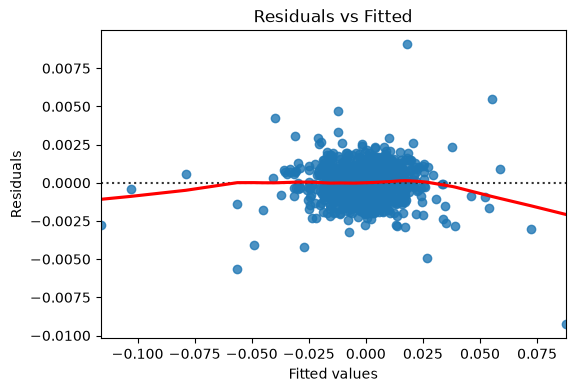

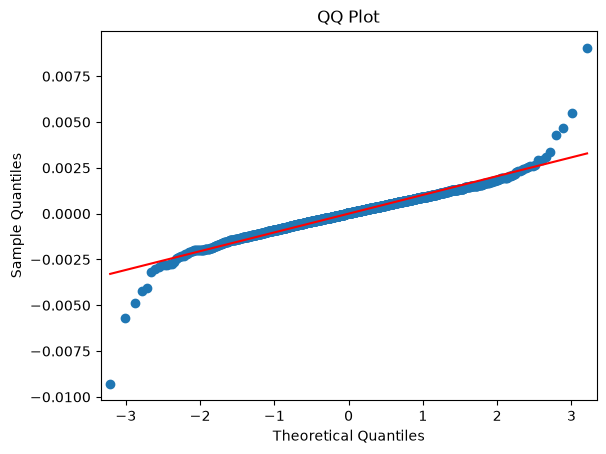

In [12]:
# Residuals vs Fitted
plt.figure(figsize=(6, 4))
sns.residplot(x=final_model.fittedvalues, y=final_model.resid, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# QQ Plot
sm.qqplot(final_model.resid, line='s')
plt.title('QQ Plot')
plt.show()

**Residuals vs fitted:** the lowess line stays flat at zero across the whole range, no missed curvature, so the linear specification is adequate.

**QQ plot:** both tails leave the line, the same fat tails Shapiro–Wilk flags, extreme joint moves are larger than a Gaussian would produce, while the center is well behaved.

## Correlation matrix

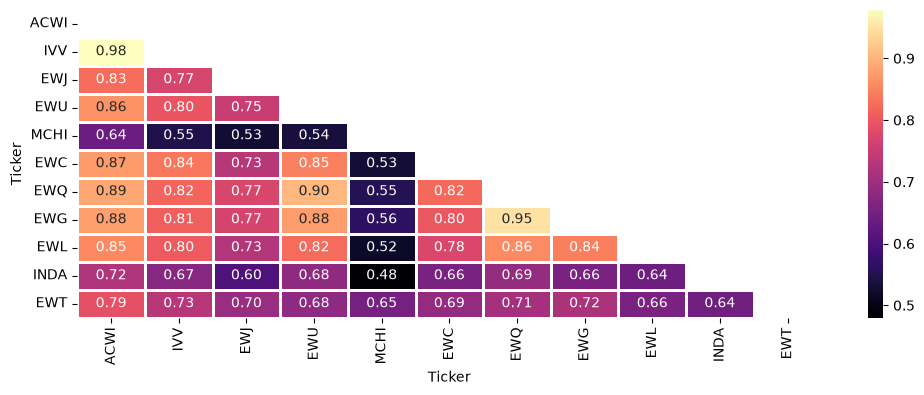

Ticker
ACWI    1.000000
IVV     0.978839
EWJ     0.826749
EWU     0.864466
MCHI    0.638208
EWC     0.873726
EWQ     0.885558
EWG     0.877606
EWL     0.854931
INDA    0.722434
EWT     0.790051
Name: ACWI, dtype: float64


In [13]:
corr = returns.corr()
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(corr, annot=True, cmap='magma', fmt='.2f', linewidths=1, mask=np.triu(corr))
plt.xticks(rotation=90)
plt.setp(plt.gca().get_xticklabels(), ha='center')
plt.show()
print(corr['ACWI'])

## \$1,000,000 portfolio, 2018-02-24 to 2024-02-24

In [14]:
components = list(X.columns)
weights = final_model.params / final_model.params.sum()
print(weights.round(4))

# the log-return replica of the regression (the tradeable price basket is built at the valuation date)
returns['ACWI_synthetic'] = returns[components].dot(weights)

portfolio = 1_000_000 * np.exp(returns[['ACWI', 'ACWI_synthetic']].cumsum())
portfolio.tail(5).map('${:,.2f}'.format)

IVV     0.6363
EWJ     0.0869
EWU     0.0862
MCHI    0.0661
EWG     0.0740
EWL     0.0506
dtype: float64


Ticker,ACWI,ACWI_synthetic
Date,,
2024-02-16,"$1,579,128.99","$1,575,192.95"
2024-02-20,"$1,574,625.18","$1,571,310.44"
2024-02-21,"$1,575,075.44","$1,573,920.80"
2024-02-22,"$1,602,247.69","$1,600,915.40"
2024-02-23,"$1,602,848.04","$1,603,106.53"


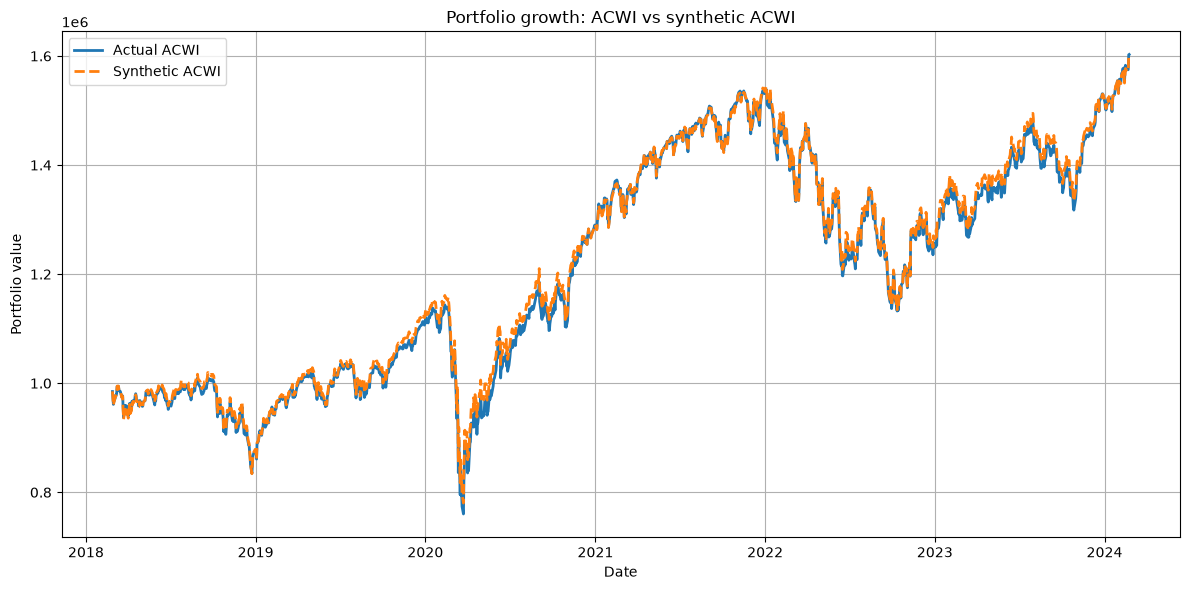

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio.index, portfolio['ACWI'], label='Actual ACWI', linewidth=2)
plt.plot(portfolio.index, portfolio['ACWI_synthetic'], label='Synthetic ACWI', linewidth=2, linestyle='--')
plt.title('Portfolio growth: ACWI vs synthetic ACWI')
plt.xlabel('Date')
plt.ylabel('Portfolio value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Market parameters as of the valuation date

Everything is estimated with information available on **2023-02-24**:
- **Risk-free rate:** the ETFs are USD assets listed on NYSE, so everything is discounted with a single USD rate: the 1-year Treasury (FRED, series DGS1) at the valuation-date close, a maturity in line with the 9- and 12-month expiries.
- **Dividend yield** of each ETF: average of the previous 5 years, estimated as the log difference between total return (adjusted prices) and price return. Averaging smooths extraordinary, non-recurring distributions that would distort a short trailing estimate (e.g. EWT, in the 10-ETF universe, paid a Dec-2022 special distribution that alone would push its 12-month yield to ~17%).
- **Volatility:** 5-year historical and EWMA (RiskMetrics, λ=0.94), which weights the recent past more heavily; both annualized.

In [16]:
valuation_date = '2023-02-24'

r_usd = float(pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS1'
                          f'&cosd={valuation_date}&coed={valuation_date}', index_col=0).iloc[0, 0]) / 100
print(f'USD risk-free rate (1-year Treasury, FRED DGS1, as of {valuation_date}): {r_usd:.2%}')

T_sample = (pd.Timestamp(valuation_date) - data.index[0]).days / 365.25
total_return = data.loc[valuation_date, components] / data.iloc[0][components]
price_return = prices.loc[valuation_date, components] / prices.iloc[0][components]
div = np.log(total_return / price_return) / T_sample

prior_returns = returns.loc[:valuation_date]
vol_hist = prior_returns.std() * np.sqrt(252)
vol_ewma = np.sqrt((prior_returns**2).ewm(alpha=0.06).mean().iloc[-1] * 252)  # RiskMetrics λ=0.94

pd.DataFrame({'historical vol': vol_hist[components + ['ACWI_synthetic']],
              'EWMA vol': vol_ewma[components + ['ACWI_synthetic']],
              'dividend yield': div}).map(lambda v: '-' if pd.isna(v) else f'{v:.2%}')

USD risk-free rate (1-year Treasury, FRED DGS1, as of 2023-02-24): 5.05%


,historical vol,EWMA vol,dividend yield
Ticker,,,
ACWI_synthetic,20.41%,14.62%,-
EWG,24.68%,18.75%,2.58%
EWJ,18.06%,14.74%,1.61%
EWL,18.77%,14.27%,2.00%
EWU,22.10%,11.87%,3.82%
IVV,21.88%,16.60%,1.81%
MCHI,29.97%,28.11%,1.42%


## Replication units and adjusted strikes

The strikes (\$85, \$87, \$78, \$100) are in ACWI-ETF terms; each component keeps the same moneyness: $K_i = S_i \cdot K / S_{ACWI}$, using traded prices.

The regression coefficients are **log-return exposures**, so the tradeable replica must hold a dollar fraction $w_i$ of each leg: $n_i = w_i \cdot S_{ACWI} / S_i$ shares of leg $i$, worth exactly $S_{ACWI}$ on the valuation date. Holding $w_i$ *shares* instead would weight the basket by price level, IVV trades near \$400 against \$25–60 for the rest, which makes such a basket 94% IVV by value: a tracker of the S&P 500, not of the ACWI. The cell below quantifies the difference over the 12-month option horizon; option quotes aggregate with the same units $n_i$ (the digital's fixed \$1 payoff aggregates with the weights themselves).

In [ ]:
S_A = prices.loc[valuation_date, 'ACWI']
S0 = prices.loc[valuation_date, components]

# n_i = w_i·S_A/S_i shares of leg i: dollar weight w_i, basket worth exactly S_A on the valuation date
units = weights * S_A / S0
prices['ACWI_synthetic'] = prices[components].mul(units).sum(axis=1)

# what holding w_i *shares* would have done over the option horizon: an S&P tracker, not an ACWI one
acwi = prices.loc[valuation_date:'2024-02-24', 'ACWI']
dollar_w = prices.loc[valuation_date:'2024-02-24', 'ACWI_synthetic']
share_w = prices.loc[valuation_date:'2024-02-24', components].dot(weights)
share_w = share_w * S_A / share_w.iloc[0]
def te(b):
    return (np.log(b / b.shift(1)) - np.log(acwi / acwi.shift(1))).std() * np.sqrt(252)
print(f'ACWI on {valuation_date}: ${S_A:.2f}')
print(f'dollar-weighted basket (n_i shares): tracking error {te(dollar_w):.2%}, ends {dollar_w.iloc[-1] - acwi.iloc[-1]:+.2f} vs ACWI')
print(f'share-weighted basket (w_i shares):  tracking error {te(share_w):.2%}, ends {share_w.iloc[-1] - acwi.iloc[-1]:+.2f} vs ACWI')

cols = components + ['ACWI_synthetic']
strikes = pd.DataFrame({K: prices.loc[valuation_date, cols] * (K / S_A) for K in [85, 87, 78, 100]})
strikes.round(2)

ACWI on 2023-02-24: $88.16
dollar-weighted basket (n_i shares): tracking error 1.16%, ends -0.59 vs ACWI
share-weighted basket (w_i shares):  tracking error 3.06%, ends +5.23 vs ACWI


,85,87,78,100
Ticker,,,,
IVV,383.84,392.87,352.23,451.58
EWJ,53.63,54.89,49.21,63.09
EWU,31.09,31.83,28.53,36.58
MCHI,46.05,47.13,42.26,54.17
EWG,26.07,26.68,23.92,30.67
EWL,42.16,43.15,38.69,49.60
ACWI_synthetic,85.00,87.00,78.00,100.00


## Black-Scholes with dividends

Call: $C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)$, $\Delta = e^{-qT} N(d_1)$.

Digital call (cash-or-nothing paying \$1): $C = e^{-rT} N(d_2)$, $\Delta = e^{-rT}\,\varphi(d_2)/(S\sigma\sqrt{T})$.

Call spread: $C = C(K_1) - C(K_2)$, $\Delta = \Delta(K_1) - \Delta(K_2)$.

Put (used only to assert put–call parity in the self-checks): $P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)$.

With $d_1 = \frac{\ln(S/K) + (r - q + \sigma^2/2)T}{\sigma\sqrt{T}}$, $d_2 = d_1 - \sigma\sqrt{T}$.

In [18]:
def bs_d1_d2(S, K, T, r, q, sigma):
    d1 = (np.log(S / K) + (r - q + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return d1, d1 - sigma * np.sqrt(T)

def call(S, K, T, r, q, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def call_delta(S, K, T, r, q, sigma):
    return np.exp(-q * T) * norm.cdf(bs_d1_d2(S, K, T, r, q, sigma)[0])

def put(S, K, T, r, q, sigma):
    d1, d2 = bs_d1_d2(S, K, T, r, q, sigma)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

def digital(S, K, T, r, q, sigma):
    return np.exp(-r * T) * norm.cdf(bs_d1_d2(S, K, T, r, q, sigma)[1])

def digital_delta(S, K, T, r, q, sigma):
    d2 = bs_d1_d2(S, K, T, r, q, sigma)[1]
    return np.exp(-r * T) * norm.pdf(d2) / (S * sigma * np.sqrt(T))

def price_series(fn, K, T_init, sigma, until, agg):
    """Daily series of fn for each component and the synthetic, from the valuation date to `until`.
    agg maps the component columns into the synthetic one: the replication units n_i for
    proportional payoffs (call, spread); the weights w_i for the digital's fixed $1 payoff and for
    call deltas (Σ n_i Δ_i S_i / S_A = Σ w_i Δ_i at the valuation date); w_i·S_i/S_A for the
    digital's delta (a per-price sensitivity). Per-component columns stay in their own terms."""
    S = prices.loc[valuation_date:until, components]
    T = T_init - (S.index - S.index[0]).days / 365
    S, T = S[T > 0], T[T > 0]
    out = pd.DataFrame(fn(S.values, strikes.loc[components, K].values, np.asarray(T)[:, None],
                          r_usd, div[components].values, sigma[components].values),
                       index=S.index, columns=components)
    out['ACWI_synthetic'] = out[components].dot(agg)
    return out

# minimal self-checks
assert abs(call(100, 80, 1, 0.0, 0.0, 1e-9) - 20) < 1e-4               # no vol, rate or dividend: intrinsic value
assert call(100, 100, 1, 0.03, 0.02, 0.2) < call(100, 100, 1, 0.03, 0.0, 0.2)  # dividends make the call cheaper
assert abs(digital(100, 80, 1, 0.0, 0.0, 1e-9) - 1) < 1e-6             # deep-ITM digital pays ~1
assert 0 < digital(100, 100, 1, 0.02, 0.0, 0.2) < np.exp(-0.02)
# put-call parity, C - P = S·e^(-qT) - K·e^(-rT): the identity a mispriced pair would break
for S_, K_, sig_ in [(100.0, 80.0, 0.15), (88.0, 87.0, 0.2), (100.0, 120.0, 0.35)]:
    assert abs(call(S_, K_, 0.75, 0.05, 0.02, sig_) - put(S_, K_, 0.75, 0.05, 0.02, sig_)
               - (S_ * np.exp(-0.02 * 0.75) - K_ * np.exp(-0.05 * 0.75))) < 1e-12

## 9-month call, strike \$85

In [19]:
call85_hist = price_series(call, 85, 0.75, vol_hist, '2023-11-24', units)
call85_ewma = price_series(call, 85, 0.75, vol_ewma, '2023-11-24', units)
delta85_hist = price_series(call_delta, 85, 0.75, vol_hist, '2023-11-24', weights)

summary = pd.DataFrame({'price (hist vol)': call85_hist.iloc[0].round(2),
                        'price (EWMA vol)': call85_ewma.iloc[0].round(2),
                        'delta % (hist vol)': (delta85_hist.iloc[0] * 100).round(2)})
print(f'As of {valuation_date}:')
summary

As of 2023-02-24:


,price (hist vol),price (EWMA vol),delta % (hist vol)
IVV,41.82,35.35,65.23
EWJ,5.24,4.69,67.49
EWU,3.10,2.08,61.32
MCHI,6.33,6.05,63.94
EWG,2.98,2.47,62.98
EWL,4.13,3.54,66.24
ACWI_synthetic,9.26,7.81,64.89


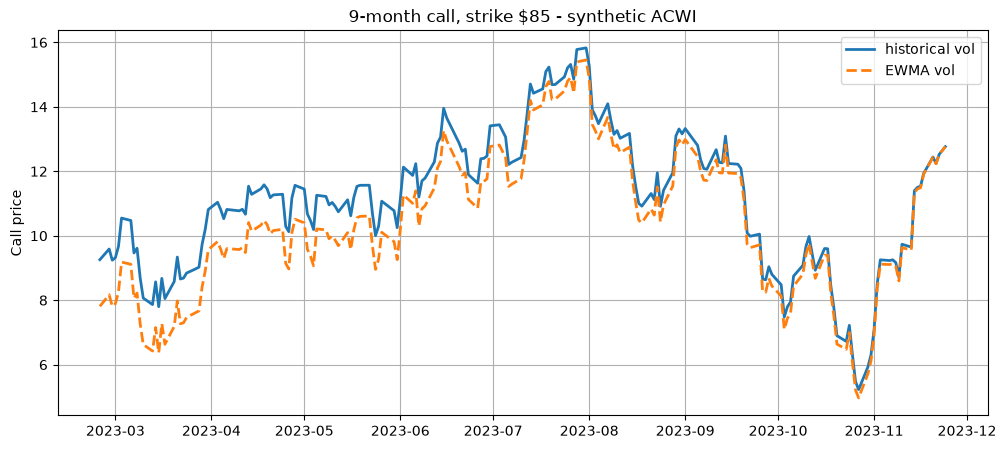

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(call85_hist.index, call85_hist['ACWI_synthetic'], label='historical vol', linewidth=2)
plt.plot(call85_ewma.index, call85_ewma['ACWI_synthetic'], label='EWMA vol', linewidth=2, linestyle='--')
plt.title('9-month call, strike $85 - synthetic ACWI')
plt.ylabel('Call price')
plt.legend()
plt.grid(True)
plt.show()

## 9-month digital call, strike \$87

In [21]:
digital87_hist = price_series(digital, 87, 0.75, vol_hist, '2023-11-24', weights)
digital87_ewma = price_series(digital, 87, 0.75, vol_ewma, '2023-11-24', weights)
deltadigital87_hist = price_series(digital_delta, 87, 0.75, vol_hist, '2023-11-24', weights * S0 / S_A)

summary = pd.DataFrame({'price (hist vol)': digital87_hist.iloc[0].round(3),
                        'price (EWMA vol)': digital87_ewma.iloc[0].round(3),
                        'delta % (hist vol)': (deltadigital87_hist.iloc[0] * 100).round(2)})
print(f'As of {valuation_date}:')
summary

As of 2023-02-24:


,price (hist vol),price (EWMA vol),delta % (hist vol)
IVV,0.521,0.554,0.51
EWJ,0.547,0.573,4.35
EWU,0.490,0.545,6.22
MCHI,0.491,0.498,3.10
EWG,0.497,0.525,6.64
EWL,0.535,0.569,5.35
ACWI_synthetic,0.518,0.550,2.29


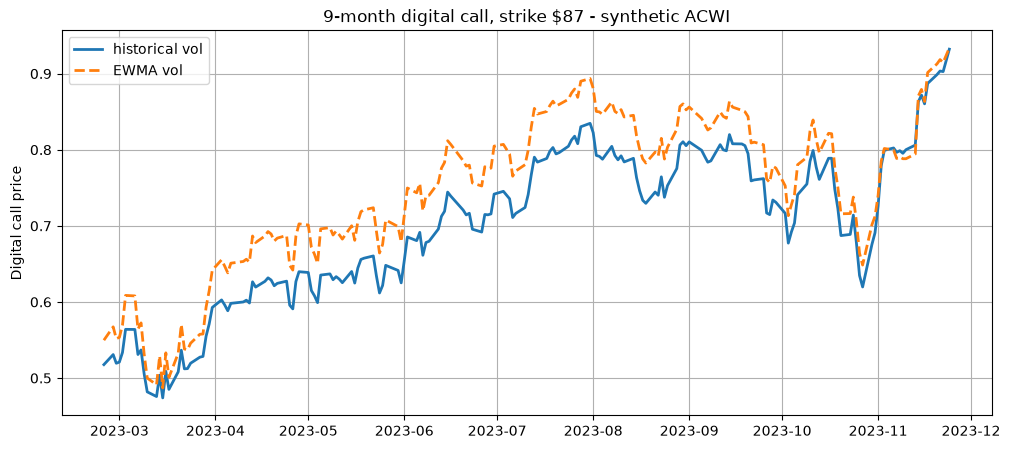

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(digital87_hist.index, digital87_hist['ACWI_synthetic'], label='historical vol', linewidth=2)
plt.plot(digital87_ewma.index, digital87_ewma['ACWI_synthetic'], label='EWMA vol', linewidth=2, linestyle='--')
plt.title('9-month digital call, strike $87 - synthetic ACWI')
plt.ylabel('Digital call price')
plt.legend()
plt.grid(True)
plt.show()

## 12-month call spread, strikes \$78 and \$100

In [23]:
spread_hist = price_series(call, 78, 1.0, vol_hist, '2024-02-24', units) - price_series(call, 100, 1.0, vol_hist, '2024-02-24', units)
spread_ewma = price_series(call, 78, 1.0, vol_ewma, '2024-02-24', units) - price_series(call, 100, 1.0, vol_ewma, '2024-02-24', units)
deltaspread_hist = price_series(call_delta, 78, 1.0, vol_hist, '2024-02-24', weights) - price_series(call_delta, 100, 1.0, vol_hist, '2024-02-24', weights)

summary = pd.DataFrame({'price (hist vol)': spread_hist.iloc[0].round(2),
                        'price (EWMA vol)': spread_ewma.iloc[0].round(2),
                        'delta % (hist vol)': (deltaspread_hist.iloc[0] * 100).round(2)})
print(f'As of {valuation_date}:')
summary

As of 2023-02-24:


,price (hist vol),price (EWMA vol),delta % (hist vol)
IVV,47.47,49.62,41.05
EWJ,6.89,7.12,48.50
EWU,3.57,3.78,40.55
MCHI,5.44,5.51,30.67
EWG,3.08,3.21,36.76
EWL,5.31,5.53,46.97
ACWI_synthetic,10.43,10.87,40.95


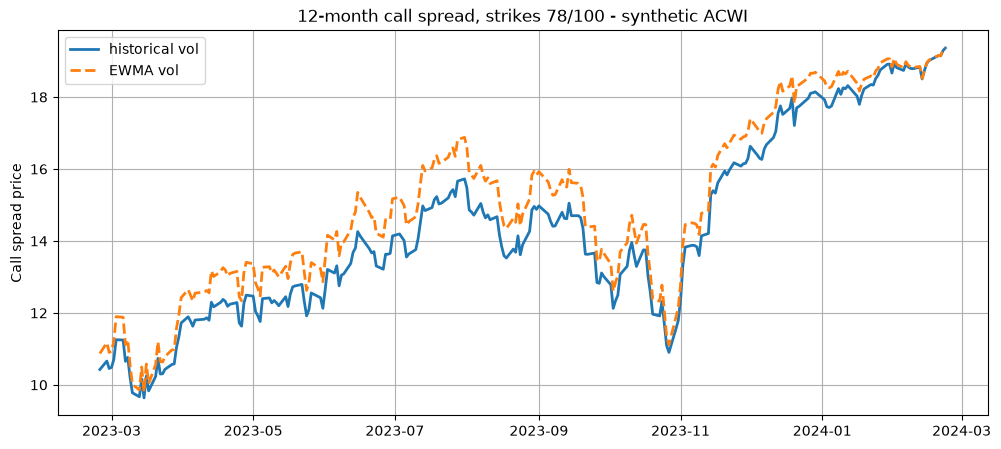

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(spread_hist.index, spread_hist['ACWI_synthetic'], label='historical vol', linewidth=2)
plt.plot(spread_ewma.index, spread_ewma['ACWI_synthetic'], label='EWMA vol', linewidth=2, linestyle='--')
plt.title('12-month call spread, strikes $78/$100 - synthetic ACWI')
plt.ylabel('Call spread price')
plt.legend()
plt.grid(True)
plt.show()

## No-arbitrage guards

Every quote this notebook emits is asserted against its model-free bounds, per component and aggregated, on every mark-to-market day:

- vanilla call: $\max(Se^{-qT} - Ke^{-rT},\, 0) \le C \le Se^{-qT}$
- digital call: $0 \le D \le e^{-rT}$
- call spread: $0 \le C(K_1) - C(K_2) \le (K_2 - K_1)\,e^{-rT}$

The aggregate bounds are the same combination of the component bounds ($\sum_i n_i \,\cdot$ for proportional payoffs, $\sum_i w_i \,\cdot$ for the digital), so they apply exactly to the basket quote; put–call parity is asserted next to the pricing functions themselves. These checks cost nothing while they pass, the point is that a scaling or weighting mistake (quoting the basket in basket terms, mixing shares with dollar weights) blows through the upper bounds immediately, so the notebook refuses to emit an out-of-bounds quote instead of relying on the numbers happening to look reasonable.

In [25]:
def _S_T_grid(T_init, until):
    S = prices.loc[valuation_date:until, components]
    T = T_init - (S.index - S.index[0]).days / 365
    return S[T > 0].values, np.asarray(T[T > 0])[:, None]

def assert_bounds(quotes, lo, hi, agg, label):
    q_c, q_a = quotes[components].values, quotes['ACWI_synthetic'].values
    assert (q_c >= lo - 1e-9).all() and (q_c <= hi + 1e-9).all(), f'{label}: component bound violated'
    assert (q_a >= lo @ agg.values - 1e-9).all() and (q_a <= hi @ agg.values + 1e-9).all(), \
        f'{label}: aggregate bound violated'
    print(f'{label}: {q_a.size} daily marks within bounds')

for label, series in [('call $85 (hist vol)', call85_hist), ('call $85 (EWMA vol)', call85_ewma)]:
    S, T = _S_T_grid(0.75, '2023-11-24')
    hi = S * np.exp(-div[components].values * T)
    lo = np.maximum(hi - strikes.loc[components, 85].values * np.exp(-r_usd * T), 0)
    assert_bounds(series, lo, hi, units, label)

for label, series in [('digital $87 (hist vol)', digital87_hist), ('digital $87 (EWMA vol)', digital87_ewma)]:
    S, T = _S_T_grid(0.75, '2023-11-24')
    assert_bounds(series, np.zeros_like(S), np.exp(-r_usd * T) * np.ones_like(S), weights, label)

for label, series in [('spread $78/$100 (hist vol)', spread_hist), ('spread $78/$100 (EWMA vol)', spread_ewma)]:
    S, T = _S_T_grid(1.0, '2024-02-24')
    width = (strikes.loc[components, 100] - strikes.loc[components, 78]).values
    assert_bounds(series, np.zeros_like(S), width * np.exp(-r_usd * T), units, label)

call $85 (hist vol): 190 daily marks within bounds
call $85 (EWMA vol): 190 daily marks within bounds
digital $87 (hist vol): 190 daily marks within bounds
digital $87 (EWMA vol): 190 daily marks within bounds
spread $78/$100 (hist vol): 251 daily marks within bounds
spread $78/$100 (EWMA vol): 251 daily marks within bounds


## Basket of options vs option on the basket

A linear combination of options is not an option on the linear combination. For convex payoffs (the call), Jensen's inequality and imperfect correlations imply that the basket of calls is worth more than the call on the synthetic index: it is a **super-replication** (whoever sells the ACWI call and buys the basket ends up over-hedged), and the difference is the correlation premium. For non-convex payoffs (the digital and the capped spread) the inequality does not apply and the sign can flip, as the table shows.

To quantify it, each option is priced directly on the synthetic index, with its own volatility and dividend yield, and the implied volatility is extracted from the basket quote.

In [26]:
S_syn = prices.loc[valuation_date, 'ACWI_synthetic']   # = S_A by construction
q_syn = (weights * div[components]).sum()              # dollar weights are the w_i themselves
v_syn = vol_hist['ACWI_synthetic']
K85s, K87s, K78s, K100s = strikes.loc['ACWI_synthetic', [85, 87, 78, 100]]
print(f'Synthetic S = ${S_syn:.2f}, synthetic q = {q_syn:.2%}, historical vol = {v_syn:.2%}')

comparison = pd.DataFrame({
    'basket of options (quote)': [call85_hist.iloc[0]['ACWI_synthetic'],
                                  digital87_hist.iloc[0]['ACWI_synthetic'],
                                  spread_hist.iloc[0]['ACWI_synthetic']],
    'option on the basket': [call(S_syn, K85s, 0.75, r_usd, q_syn, v_syn),
                             digital(S_syn, K87s, 0.75, r_usd, q_syn, v_syn),
                             call(S_syn, K78s, 1.0, r_usd, q_syn, v_syn) - call(S_syn, K100s, 1.0, r_usd, q_syn, v_syn)],
}, index=['Call $85 (9m)', 'Digital call $87 (9m)', 'Call spread $78/$100 (12m)'])
comparison['correlation premium'] = comparison.iloc[:, 0] - comparison.iloc[:, 1]
comparison.round(3)

Synthetic S = $88.16, synthetic q = 2.01%, historical vol = 20.41%


,basket of options (quote),option on the basket,correlation premium
Call $85 (9m),9.257,8.772,0.484
Digital call $87 (9m),0.518,0.526,-0.008
Call spread $78/$100 (12m),10.427,10.557,-0.130


In [27]:
C_basket = call85_hist.iloc[0]['ACWI_synthetic']
implied_vol_syn = brentq(lambda s: call(S_syn, K85s, 0.75, r_usd, q_syn, s) - C_basket, 1e-4, 3.0)
print(f'Implied volatility of the synthetic call quote: {implied_vol_syn:.2%}')
print(f'Historical volatility of the synthetic index:   {v_syn:.2%}')

Implied volatility of the synthetic call quote: 22.17%
Historical volatility of the synthetic index:   20.41%


## Skew sensitivity: where flat vol actually bites

The digital and the spread live next to their strikes, exactly where the flat-vol assumption is weakest. On a real surface a cash-or-nothing digital is the tight-call-spread limit $-\partial C/\partial K$ taken *along the skew*, which adds $-\text{Vega} \cdot \partial\sigma/\partial K$ to the flat-vol $e^{-rT}N(d_2)$; with the negative skew typical of equity indices that correction is positive, so flat vol systematically under-quotes a digital, the reason desks replicate digitals as tight call spreads on the surface instead of pricing the formula. The \$78/\$100 spread straddles two strikes and picks up the skew *difference* between them. The vanilla call is convex and near the money, so it barely reacts.

There is no listed ACWI surface to calibrate to, that absence is the premise of the whole exercise, so the headline quotes stay flat-vol and the exposure is quantified instead: every leg is repriced under a linear skew in log-moneyness, $\sigma_i(K) = \sigma_i + s \cdot \ln(K/S_{ACWI})/10\%$, sweeping the slope $s$ over the range typical of equity indices (0 to −3 vol points per 10% of moneyness; all legs share the ACWI option's moneyness by construction, so the same shift applies across legs). The digital is repriced the way a desk would trade it: a call spread ±1% around the strike, each leg on its skewed vol.

In [28]:
def basket_call_skew(K, T, slope):
    """Basket-of-calls quote with each leg on a skewed vol; slope in vol pts per 10% log-moneyness."""
    sig = vol_hist[components].values + slope / 100 * np.log(K / S_A) / 0.10
    return (units.values * call(S0.values, S0.values * K / S_A, T, r_usd, div[components].values, sig)).sum()

h = 0.87   # the ±1% call-spread replication of the $1 digital payoff
slopes = [0, -1, -2, -3]
skew_table = pd.DataFrame({
    'call $85 (9m)': {s: basket_call_skew(85, 0.75, s) for s in slopes},
    'digital $87 (9m)': {s: (basket_call_skew(87 - h, 0.75, s) - basket_call_skew(87 + h, 0.75, s)) / (2 * h)
                         for s in slopes},
    'call spread $78/$100 (12m)': {s: basket_call_skew(78, 1.0, s) - basket_call_skew(100, 1.0, s) for s in slopes}})
skew_table.index.name = 'skew slope (vol pts per 10% moneyness)'
pd.concat([skew_table.round(3), (skew_table / skew_table.iloc[0] - 1).map('{:+.1%}'.format)],
          axis=1, keys=['price', 'vs flat vol'])

price                   \
                                       call $85 (9m) digital $87 (9m)   
skew slope (vol pts per 10% moneyness)                                  
 0                                             9.257            0.518   
-1                                             9.357            0.550   
-2                                             9.458            0.582   
-3                                             9.559            0.615   

                                                                   \
                                       call spread $78/$100 (12m)   
skew slope (vol pts per 10% moneyness)                              
 0                                                         10.427   
-1                                                         11.144   
-2                                                         11.863   
-3                                                         12.581   

                                         vs flat vol                   \
                                       call $85 (9m) digital $87 (9m)   
skew slope (vol pts per 10% moneyness)                                  
 0                                             +0.0%            +0.0%   
-1                                             +1.1%            +6.3%   
-2                                             +2.2%           +12.5%   
-3                                             +3.3%           +18.8%   

                                                                   
                                       call spread $78/$100 (12m)  
skew slope (vol pts per 10% moneyness)                             
 0                                                          +0.0%  
-1                                                          +6.9%  
-2                                                         +13.8%  
-3                                                         +20.7%

At the steep end of the sweep the call moves 3.3%, the flat-vol \$9.26 headline is robust. The digital gains up to 18.8% (\$0.52 → \$0.62) and the spread up to 20.7% (\$10.43 → \$12.58): under a realistic negative skew both are **under-quoted** by flat vol, so part of their negative hedging P&L in the backtest below is a flat-vol artifact rather than pure concentrated gamma, sold at a skew-consistent price they would have carried an extra 6–20% of premium as cushion. (At slope 0 the ±1% call-spread replication reproduces the closed-form digital quote of \$0.518, confirming the two views are consistent.)

## Delta-hedging backtest

Validation of the quotes: each option is sold at the basket premium (historical vol) and delta-hedged daily with the synthetic underlying until expiry. Cash accrues at the USD rate and the position in the underlying earns its dividend yield. A small P&L relative to the premium indicates that the quote and its deltas are consistent with the realized path; products with concentrated gamma (the digital near the strike) show a larger hedging error, which is why in practice they are quoted with an extra margin or replicated with a call spread.

In [29]:
def hedge_backtest(premium, delta_fn, payoff, T_init, until):
    S = prices.loc[valuation_date:until, 'ACWI_synthetic']
    T = np.maximum(T_init - (S.index - S.index[0]).days / 365, 1e-9)
    delta = delta_fn(S.values, T)
    cash = premium - delta[0] * S.iloc[0]
    for i in range(1, len(S)):
        dt = T[i - 1] - T[i]
        cash = cash * np.exp(r_usd * dt) + delta[i - 1] * S.iloc[i - 1] * q_syn * dt
        cash -= (delta[i] - delta[i - 1]) * S.iloc[i]
    pnl = delta[-1] * S.iloc[-1] + cash - payoff(S.iloc[-1])
    return {'premium received': premium, 'final S': S.iloc[-1], 'payoff paid': payoff(S.iloc[-1]),
            'hedging P&L': pnl, 'P&L % of premium': pnl / premium * 100}

results = pd.DataFrame({
    'Call $85 (9m)': hedge_backtest(
        call85_hist.iloc[0]['ACWI_synthetic'],
        lambda s, t: call_delta(s, K85s, t, r_usd, q_syn, v_syn),
        lambda s: max(s - K85s, 0), 0.75, '2023-11-24'),
    'Digital call $87 (9m)': hedge_backtest(
        digital87_hist.iloc[0]['ACWI_synthetic'],
        lambda s, t: digital_delta(s, K87s, t, r_usd, q_syn, v_syn),
        lambda s: float(s > K87s), 0.75, '2023-11-24'),
    'Call spread $78/$100 (12m)': hedge_backtest(
        spread_hist.iloc[0]['ACWI_synthetic'],
        lambda s, t: call_delta(s, K78s, t, r_usd, q_syn, v_syn) - call_delta(s, K100s, t, r_usd, q_syn, v_syn),
        lambda s: np.clip(s - K78s, 0, K100s - K78s), 1.0, '2024-02-24'),
}).T
results.round(3)

,premium received,final S,payoff paid,hedging P&L,P&L % of premium
Call $85 (9m),9.257,97.468,12.468,2.179,23.539
Digital call $87 (9m),0.518,97.468,1.000,-0.214,-41.329
Call spread $78/$100 (12m),10.427,106.178,22.000,-3.564,-34.182


## Monte Carlo: multivariate hedging error and the correlation premium realized

The backtest above is one realized path, and a single-asset simulation of the synthetic index could not test the thesis of this notebook: with one GBM the only thing a hedging simulation can produce is rebalancing error, so it validates the machinery, never the aggregation, correlation P&L cannot arise by construction. Here the six legs are simulated **jointly** as correlated GBMs, with the correlation matrix estimated on the same window as the vols, and each product is sold at its basket-of-options quote and delta-hedged daily with the synthetic underlying, exactly as in the backtest. Two scenarios per product:

- **realized σ = quoted σ, historical correlation:** every leg realizes exactly the vol it was priced at, so the mean P&L isolates what the aggregation itself earns or costs, the correlation premium of the pricing section, showing up as realized hedging P&L instead of a pricing footnote;
- **realized σ = EWMA, historical correlation:** the margin embedded in quoting at 5-year historical vol if the recent, lower-vol regime persists, the scenario closest to what 2023 actually delivered, so its 5th–95th band is the fair error bar on the single-path backtest numbers above.

In [30]:
corr_hist = prior_returns[components].corr().values

def mc_hedge_basket(quote, delta_fn, payoff, T0, vols, n_sims=5000, seed=42):
    """Sell at the basket-of-options quote and delta-hedge the synthetic index daily; the six
    legs follow correlated GBMs (historical correlation, per-leg vols) and the synthetic is
    their dollar-weighted basket, exactly as in the realized backtest."""
    rng = np.random.default_rng(seed)
    m = round(T0 * 252)
    dt = T0 / m
    cov = corr_hist * np.outer(vols[components], vols[components])
    steps = (r_usd - div[components].values - np.diag(cov) / 2) * dt \
            + rng.standard_normal((m, n_sims, len(components))) @ np.linalg.cholesky(cov).T * np.sqrt(dt)
    legs = S0.values * np.exp(np.concatenate([np.zeros((1, n_sims, len(components))), np.cumsum(steps, axis=0)]))
    S = legs @ units.values
    T = T0 - np.arange(m)[:, None] * dt
    delta = delta_fn(S[:-1], T)
    cash = quote - delta[0] * S[0]
    for i in range(1, m):
        cash = cash * np.exp(r_usd * dt) + delta[i - 1] * S[i - 1] * q_syn * dt
        cash -= (delta[i] - delta[i - 1]) * S[i]
    cash = cash * np.exp(r_usd * dt) + delta[-1] * S[-2] * q_syn * dt
    pnl = delta[-1] * S[-1] + cash - payoff(S[-1])
    return pnl / quote * 100

products = {
    'call $85 (9m)': (call85_hist.iloc[0]['ACWI_synthetic'],
                      lambda s, t: call_delta(s, K85s, t, r_usd, q_syn, v_syn),
                      lambda s: np.maximum(s - K85s, 0), 0.75),
    'digital $87 (9m)': (digital87_hist.iloc[0]['ACWI_synthetic'],
                         lambda s, t: digital_delta(s, K87s, t, r_usd, q_syn, v_syn),
                         lambda s: (s > K87s).astype(float), 0.75),
    'spread $78/$100 (12m)': (spread_hist.iloc[0]['ACWI_synthetic'],
                              lambda s, t: call_delta(s, K78s, t, r_usd, q_syn, v_syn)
                                           - call_delta(s, K100s, t, r_usd, q_syn, v_syn),
                              lambda s: np.clip(s - K78s, 0, K100s - K78s), 1.0),
}
mc = pd.DataFrame({(name, scen): mc_hedge_basket(quote, delta_fn, payoff, T0, vols)
                   for name, (quote, delta_fn, payoff, T0) in products.items()
                   for scen, vols in [('realized σ = quoted', vol_hist), ('realized σ = EWMA', vol_ewma)]})
mc.describe(percentiles=[0.05, 0.5, 0.95]).round(2)

call $85 (9m)                      digital $87 (9m)  \
      realized σ = quoted realized σ = EWMA realized σ = quoted   
count             5000.00           5000.00             5000.00   
mean                 5.53             20.50               -1.32   
std                  3.98              6.23               21.26   
min                -17.23              6.67             -189.07   
5%                  -0.83             11.10              -24.52   
50%                  5.48             20.04               -1.58   
95%                 12.14             31.50               23.11   
max                 23.38             42.85              145.72   

                        spread $78/$100 (12m)                    
      realized σ = EWMA   realized σ = quoted realized σ = EWMA  
count           5000.00               5000.00           5000.00  
mean              -7.93                 -1.26             -6.02  
std               28.65                  3.87             12.33  
min             -167.83                -19.60            -38.16  
5%               -51.62                 -7.67            -24.69  
50%              -11.77                 -1.19             -7.39  
95%               37.10                  4.83             13.28  
max              159.02                 20.14             24.77

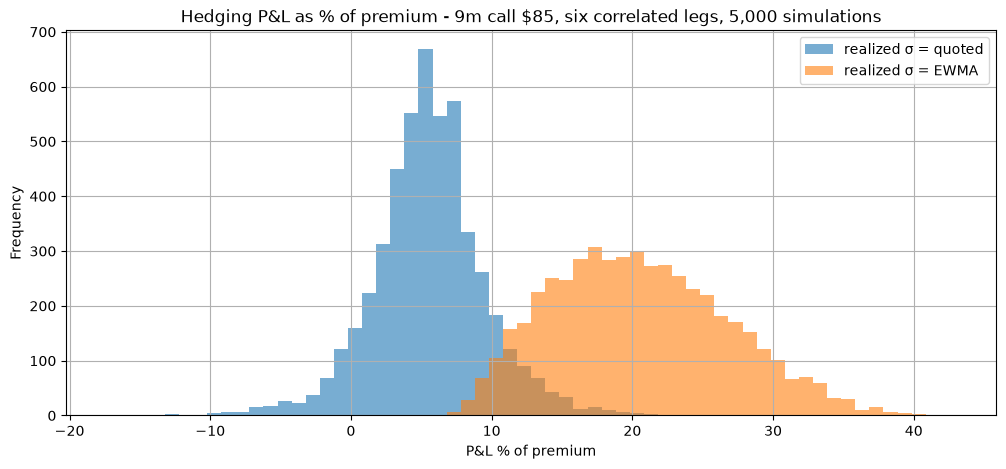

In [31]:
mc['call $85 (9m)'].plot.hist(bins=60, alpha=0.6, figsize=(12, 5),
    title='Hedging P&L as % of premium - 9m call $85, six correlated legs, 5,000 simulations')
plt.xlabel('P&L % of premium')
plt.grid(True)
plt.show()

In [32]:
premium_check = pd.DataFrame({
    name: {'mean MC P&L at quoted vols ($)': mc[(name, 'realized σ = quoted')].mean() / 100 * quote,
           'correlation premium of the pricing section ($)': comparison['correlation premium'].iloc[j]}
    for j, (name, (quote, *_)) in enumerate(products.items())}).T
premium_check.round(3)

,mean MC P&L at quoted vols ($),correlation premium of the pricing section ($)
call $85 (9m),0.512,0.484
digital $87 (9m),-0.007,-0.008
spread $78/$100 (12m),-0.131,-0.130


Two independent computations agree: the mean P&L of hedging at the quoted vols reproduces the correlation premium of the pricing section for all three products (+\$0.51 vs +\$0.48 on the call, and matching to the cent on the digital and the spread; the small gaps are the basket-of-lognormals ≠ lognormal approximation plus discrete-rebalancing error). The premium the basket quote charges for imperfect correlation is not a pricing artifact; it is collected, path by path, by the seller who hedges the basket, and its sign flips for the non-convex payoffs exactly as the pricing table said it should.

The EWMA scenario puts error bars on the single-path backtest: the call's realized +23.5% sits near the middle of its band (mean +20.5%, 5th–95th +11.1% to +31.5%), and the digital's −41.3% is inside its wide band (−51.6% to +37.1%), concentrated gamma, as advertised, now with a distribution around it. The spread's realized −34.2% falls *below* its 5th percentile (−24.7%): 2023–24 was a nearly one-way rally through the short strike, the kind of trending path that a GBM with independent increments underweights, a reminder that these bands carry the model's own assumptions, not just its parameters.